In [1]:
#!/usr/bin/env python

import os
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from datetime import datetime
from isoweek import Week
from cmdstanpy import CmdStanModel
from cmdstanpy import from_csv
import glob

In [2]:
# Parse ISO week format (e.g. "2020-W12") into a date (Monday of that ISO week)
def iso_week_to_date(iso_str):
    """
    Convert 'YYYY-Www' string into date.
    Example: "2020-W12" -> Monday of the 12th ISO week of 2020.
    """
    match = re.match(r"(\d{4})-W(\d{1,2})", iso_str)
    if not match:
        return None
    year, week = match.groups()
    year, week = int(year), int(week)
    return Week(year, week).monday()

In [3]:
# Read the 2010-2025 DK data
df = pd.read_csv("data/DK_2010_2025_posfrac.csv", dtype=str)
df["value"] = pd.to_numeric(df["PosFrac"])

# Create a 'date' column from 'year_Week'
df["date"] = df["year_Week"].apply(iso_week_to_date)
df['date'] = pd.to_datetime(df["date"])

print(df['date'])

0     2010-01-04
1     2010-01-11
2     2010-01-18
3     2010-01-25
4     2010-02-01
         ...    
793   2025-02-24
794   2025-03-03
795   2025-03-10
796   2025-03-17
797   2025-03-24
Name: date, Length: 798, dtype: datetime64[ns]


In [4]:
len(df['date'])

798

In [5]:
# Load in stan data:
csv_files = glob.glob('stan_output/sinusoid_2025/*20250801092152*.csv')

print(csv_files)

fit = from_csv(csv_files)

['stan_output/sinusoid_2025/sirs_sinusoid_dt-20250801092152_1.csv', 'stan_output/sinusoid_2025/sirs_sinusoid_dt-20250801092152_4.csv', 'stan_output/sinusoid_2025/sirs_sinusoid_dt-20250801092152_2.csv', 'stan_output/sinusoid_2025/sirs_sinusoid_dt-20250801092152_3.csv']


In [6]:
print(fit.diagnose())

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



In [7]:
print("Parameter means:")
for var in ['S0', 'logx_I0', 'beta0', 'dbeta', 'betaphase', 'sigma_obs', 'rho', 'delta']:
#for var in ['S0', 'I0', 'beta0', 'dbeta', 'betaphase', 'sigma_obs', 'rho', 'tau']:
    print(f"{var}: {fit.stan_variable(var).mean()}")

Parameter means:
S0: 0.6458905435
logx_I0: -2.6409258616666667
beta0: 0.649645859
dbeta: 0.18228653116666668
betaphase: 3.6441056533333334
sigma_obs: 0.016210041683333336
rho: 0.021266319516666667
delta: 0.0023089227783333333


In [8]:
# Extract confidence intervals using arviz

import arviz as az

idata = az.from_cmdstanpy(fit)
for var in ['S0', 'logx_I0', 'beta0', 'dbeta', 'betaphase', 'sigma_obs', 'rho', 'delta']:
    hpd = az.hdi(idata, var_names=[var], hdi_prob=0.95)

    print(f"{var}: {fit.stan_variable(var).mean()}" + "\t\t" + f"[{np.float64(hpd[var][0])} ; {np.float64(hpd[var][1])}]")
    if var=="delta":
        print(f"1/{var}: {(1/52)*1/fit.stan_variable(var).mean()} years" + "\t\t" + f"[{(1/52)*1/np.float64(hpd[var][1])} ; {(1/52)*1/np.float64(hpd[var][0])}]")

S0: 0.6458905435		[0.569548 ; 0.72392]
logx_I0: -2.6409258616666667		[-2.68789 ; -2.59338]
beta0: 0.649645859		[0.577625 ; 0.725841]
dbeta: 0.18228653116666668		[0.171415 ; 0.193153]
betaphase: 3.6441056533333334		[3.59002 ; 3.69423]
sigma_obs: 0.016210041683333336		[0.015398 ; 0.0170789]
rho: 0.021266319516666667		[0.0187612 ; 0.0239006]
delta: 0.0023089227783333333		[0.0015968 ; 0.00302681]
1/delta: 8.328892335087412 years		[6.353477499667713 ; 12.043317404038847]


I0 posterior mean +- sd: 0.001475 +- 0.000066


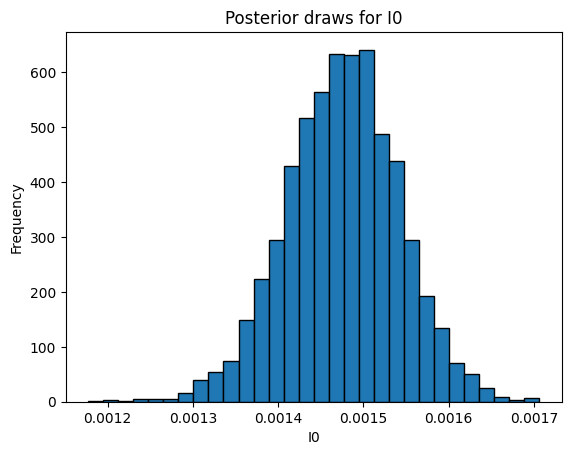

In [9]:
# Visualize draws for variable:
#var = 'sigma_obs'
#var = 'rho'
#var = 'beta0'
#var = 'betaphase'
#var = 'dbeta'
#var = 'delta'
var = 'I0'
#var = 'S0'
#var = 'x_I0'
#var = 'logx_I0'

v_samples = fit.stan_variable(var)

# Mean and standard deviation:
mean_v = v_samples.mean()
sd_v = v_samples.std()

print(f"{var} posterior mean +- sd: {mean_v:.6f} +- {sd_v:.6f}")
if var=='delta':
    print(f"1/(mean({var})) = {1/mean_v:.3f} weeks = {(1/52)*1/mean_v:.3f} years")
    print(f"+ standard deviation: 1/(mean({var})) = {1/(mean_v+sd_v):.3f} weeks = {(1/52)*1/(mean_v+sd_v):.3f} years")
    print(f"- standard deviation: 1/(mean({var})) = {1/(mean_v-sd_v):.3f} weeks = {(1/52)*1/(mean_v-sd_v):.3f} years")

plt.hist(v_samples, bins=30, edgecolor='k')
plt.title("Posterior draws for " + var)
plt.xlabel(var)
plt.ylabel("Frequency")
plt.show()


1317


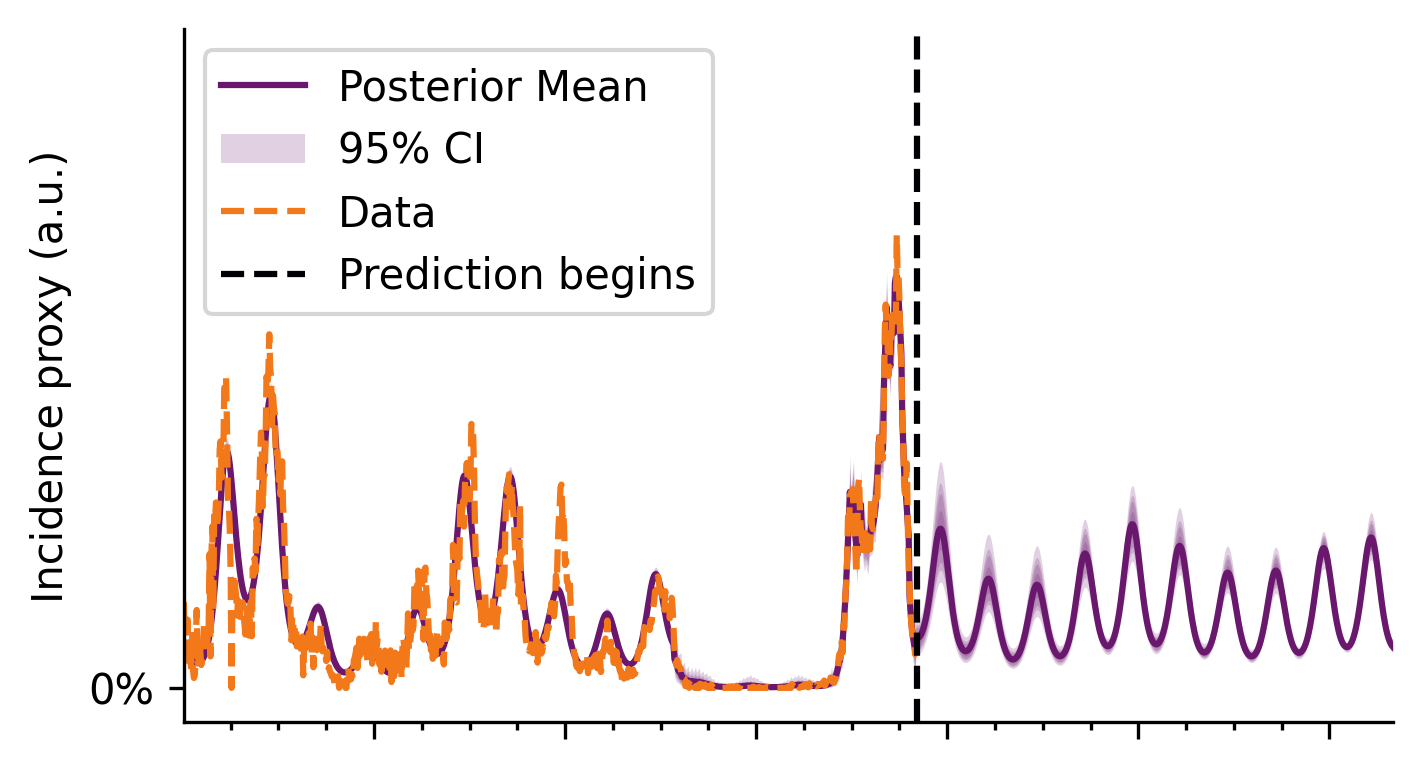

In [10]:
var = "Ifit"


include_xticks = False

v_draws = fit.stan_variable(var)
print(v_draws.shape[1])

plt.figure(figsize=(5.2, 3), dpi=300)

############

# v_draws.shape = (num_draws, N + Npred)
mean_v = np.mean(v_draws, axis=0)  # average over draws
lower_v = np.percentile(v_draws, 2.5, axis=0)  # 2.5% quantile
upper_v = np.percentile(v_draws, 97.5, axis=0) # 97.5% quantilel

time_fit = np.arange(1, v_draws.shape[1] + 1)/52 + 2010
time_data = np.arange(1, len(df['value']) + 1)/52 + 2010

plt.plot(time_fit, mean_v, label='Posterior Mean', color=plt.cm.inferno(0.3))


plt.fill_between(time_fit, lower_v, upper_v, color=plt.cm.inferno(0.3), alpha=0.2, label='95% CI', lw=0)
for ci in [85, 75, 50]:
    ci_lower = (100-ci)/2
    ci_upper = ci + (100-ci)/2
    lower_v = np.percentile(v_draws, ci_lower, axis=0) 
    upper_v = np.percentile(v_draws, ci_upper, axis=0)
    plt.fill_between(time_fit, lower_v, upper_v, color=plt.cm.inferno(0.3), alpha=0.2, lw=0)

#plt.plot(df['value'] / (np.mean(fit.stan_variable("rho"))), label="data" )
plt.plot(time_data, df['value'], "--", label="Data", color=plt.cm.inferno(0.7))

prediction_start_date = time_data[-1]+1/52
color = plt.cm.inferno(0.0)
plt.axvline(prediction_start_date, ls="--", color=color, label="Prediction begins")

plt.xticks(np.arange(2010,2035))
xticklabels = []
ax=plt.gca()
n=4
for i, tick in enumerate(ax.xaxis.get_major_ticks()):
    if i % n == 0:
        tick.tick1line.set_markersize(4)  # tick length
        tick.tick2line.set_markersize(4)
        if include_xticks:
            xticklabels.append(i+2010)
        else:
            xticklabels.append('')
    else:
        tick.tick1line.set_markersize(2)  # tick length
        tick.tick2line.set_markersize(2)
        xticklabels.append('')

plt.xticks(np.arange(2010,2035), labels=xticklabels)
plt.yticks([0], labels=['0%'])
if include_xticks:
    plt.xlabel('Time')

plt.ylabel("Incidence proxy (a.u.)")
#plt.title('Posterior Mean and 95% CI for ' + var)
plt.legend(loc="upper left")

plt.ylim([-0.021, 0.4])
plt.xlim([time_fit[0], time_fit[-1]])

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.show()


2010-01-04 00:00:00
[Timestamp('2010-01-05 00:00:00'), Timestamp('2012-01-01 00:00:00'), Timestamp('2014-01-01 00:00:00'), Timestamp('2016-01-01 00:00:00'), Timestamp('2018-01-01 00:00:00'), Timestamp('2020-01-01 00:00:00'), Timestamp('2022-01-01 00:00:00'), Timestamp('2024-01-01 00:00:00'), Timestamp('2026-01-01 00:00:00'), Timestamp('2028-01-01 00:00:00'), Timestamp('2030-01-01 00:00:00'), Timestamp('2032-01-01 00:00:00'), Timestamp('2034-01-01 00:00:00'), Timestamp('2025-01-01 00:00:00')]


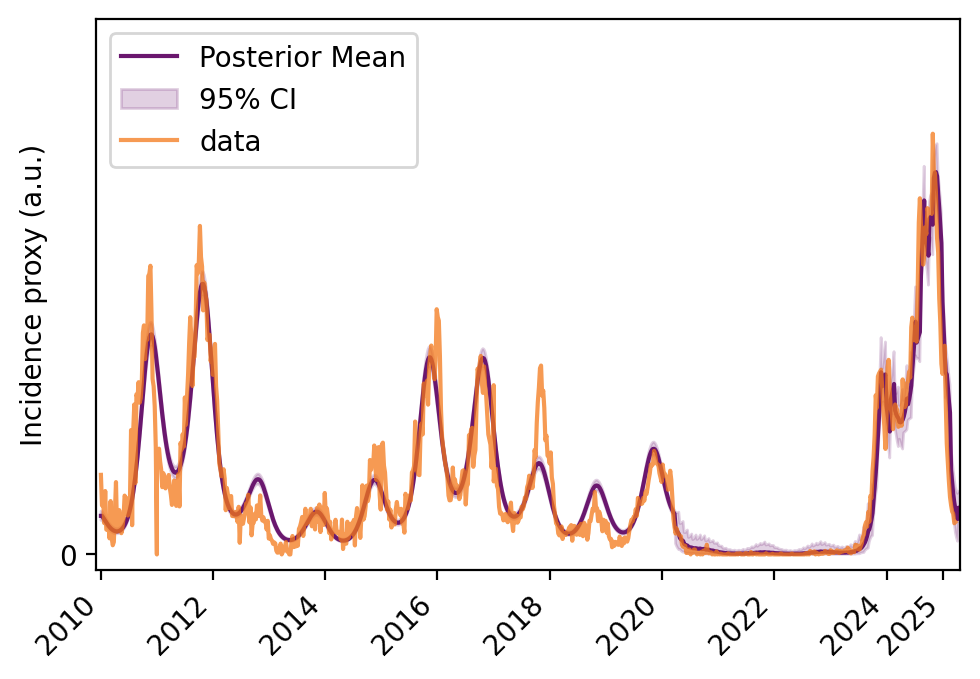

In [11]:
import matplotlib.dates as mdates
from matplotlib.dates import DateFormatter

start_date = df["date"].iloc[0]
print(start_date)
n_time_points = v_draws.shape[1]
time_axis = pd.date_range(start=start_date, periods=n_time_points, freq="W-MON")

mean_v = np.mean(v_draws, axis=0)
lower_v = np.percentile(v_draws, 2.5, axis=0)
upper_v = np.percentile(v_draws, 97.5, axis=0)

plt.figure(figsize=(5, 3.5), dpi=200)
plt.plot(time_axis, mean_v, label='Posterior Mean', color=plt.cm.inferno(0.3))
plt.fill_between(time_axis, lower_v, upper_v, color=plt.cm.inferno(0.3), alpha=0.2, label='95% CI')

# Plot data
plt.plot(df["date"], df["value"], "-", label="data", color=plt.cm.inferno(0.7), alpha=0.75)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=24))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))


my_xticks = []

curr_date = pd.to_datetime("2010.1.5")
my_xticks.append(curr_date)

curr_date_int = 2012
curr_date = pd.to_datetime(str(curr_date_int) + ".1") 
while curr_date < time_axis[-1]:
    my_xticks.append(curr_date)
    curr_date_int += 2
    curr_date = pd.to_datetime(str(curr_date_int))

curr_date = pd.to_datetime("2025.1.1")
my_xticks.append(curr_date)

print(my_xticks)

plt.xticks(my_xticks)
plt.yticks([0])

plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

#plt.xlabel("Time")
plt.ylabel("Incidence proxy (a.u.)")

plt.legend()
plt.tight_layout()
plt.xlim([start_date - pd.to_timedelta(30, unit='D'), df["date"].iloc[-1] + pd.to_timedelta(30, unit='D') ])

plt.ylim([-0.01, 0.35])

plt.show()


1317
1317


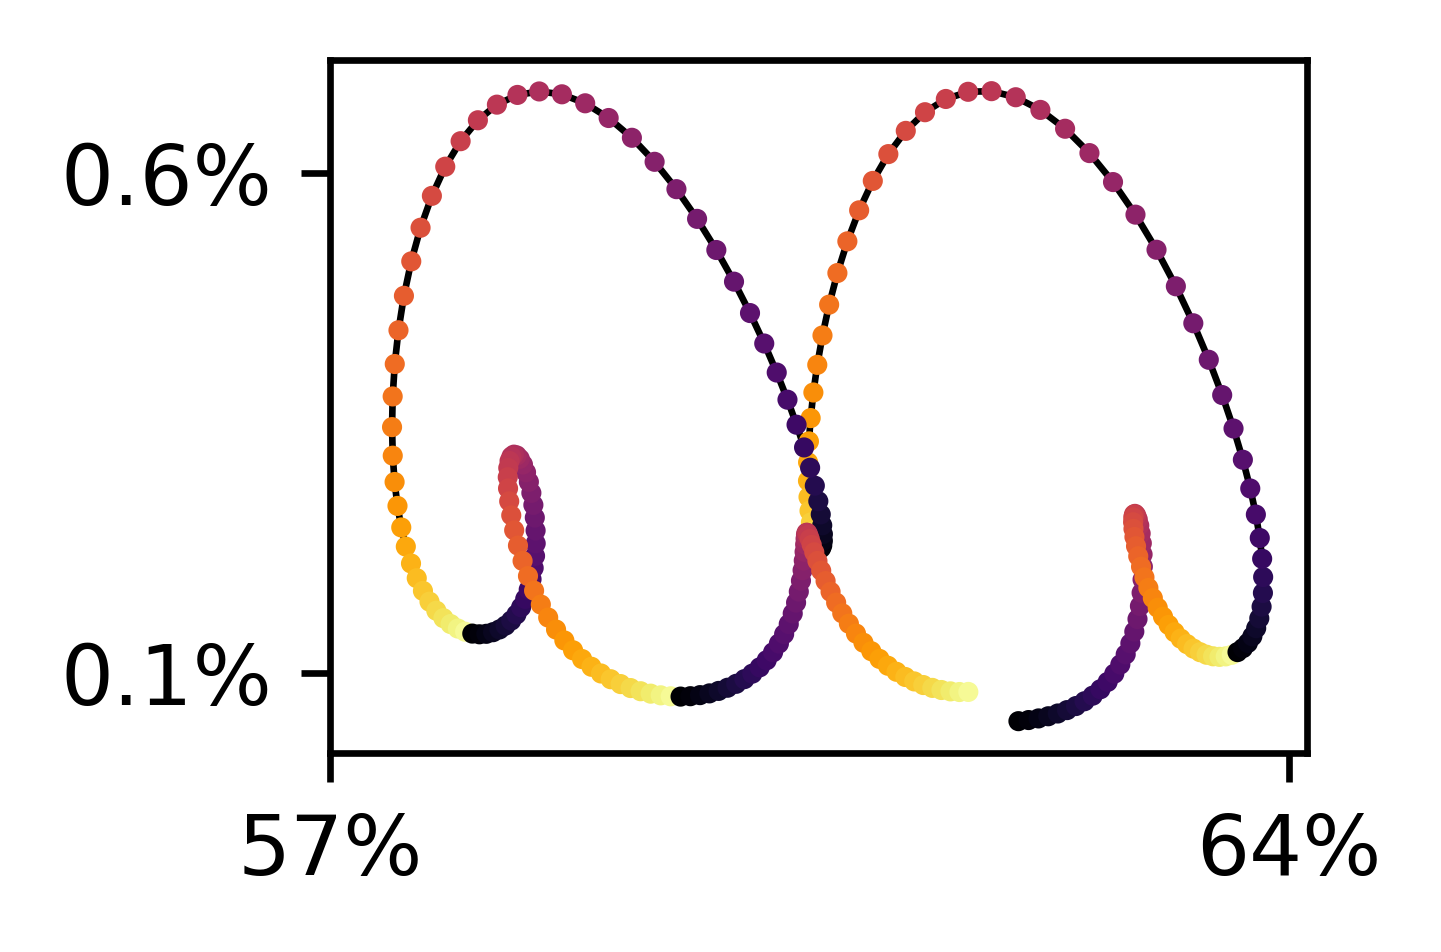

In [13]:
# Configuration space (S, I) plot:
fig = plt.figure(figsize=(2.1, 1.5), dpi=600)

############
var = 'S'
S_draws = fit.stan_variable(var)
print(S_draws.shape[1])
# v_draws.shape = (num_draws, N + Npred)
mean_S = np.mean(S_draws, axis=0)  # average over draws
lower_S = np.percentile(S_draws, 2.5, axis=0)  # 2.5% quantile
upper_S = np.percentile(S_draws, 97.5, axis=0) # 97.5% quantile

var = 'I'
I_draws = fit.stan_variable(var)
print(I_draws.shape[1])
# v_draws.shape = (num_draws, N + Npred)
mean_I = np.mean(I_draws, axis=0)  # average over draws
lower_I = np.percentile(I_draws, 2.5, axis=0)  # 2.5% quantile
upper_I = np.percentile(I_draws, 97.5, axis=0) # 97.5% quantile

t_min = 2014.423
#t_min = 2010.4
t_max = t_min+5.0
plot_mask = np.logical_and(time_fit < t_max, time_fit >= t_min)

times = time_fit[plot_mask]

color_array = plt.cm.inferno((times-t_min) % 1)


plt.plot(100*mean_S[plot_mask], 100*mean_I[plot_mask], color="black", zorder=1, lw=0.8)
plt.scatter(100*mean_S[plot_mask], 100*mean_I[plot_mask], color=color_array, s=2, zorder=2)

plt.xticks([57, 64], labels=['57%', '64%'])
plt.yticks([0.1, 0.6], labels=['0.1%', '0.6%'])

#plt.xlabel("S (%)")
#plt.ylabel("I (%)")
fig.savefig('insert.png', transparent=True, bbox_inches='tight')

2010-01-04 00:00:00
[Timestamp('2010-01-05 00:00:00'), Timestamp('2012-01-01 00:00:00'), Timestamp('2014-01-01 00:00:00'), Timestamp('2016-01-01 00:00:00'), Timestamp('2018-01-01 00:00:00'), Timestamp('2020-01-01 00:00:00'), Timestamp('2022-01-01 00:00:00'), Timestamp('2024-01-01 00:00:00'), Timestamp('2026-01-01 00:00:00'), Timestamp('2028-01-01 00:00:00'), Timestamp('2030-01-01 00:00:00'), Timestamp('2032-01-01 00:00:00'), Timestamp('2034-01-01 00:00:00'), Timestamp('2025-01-01 00:00:00')]


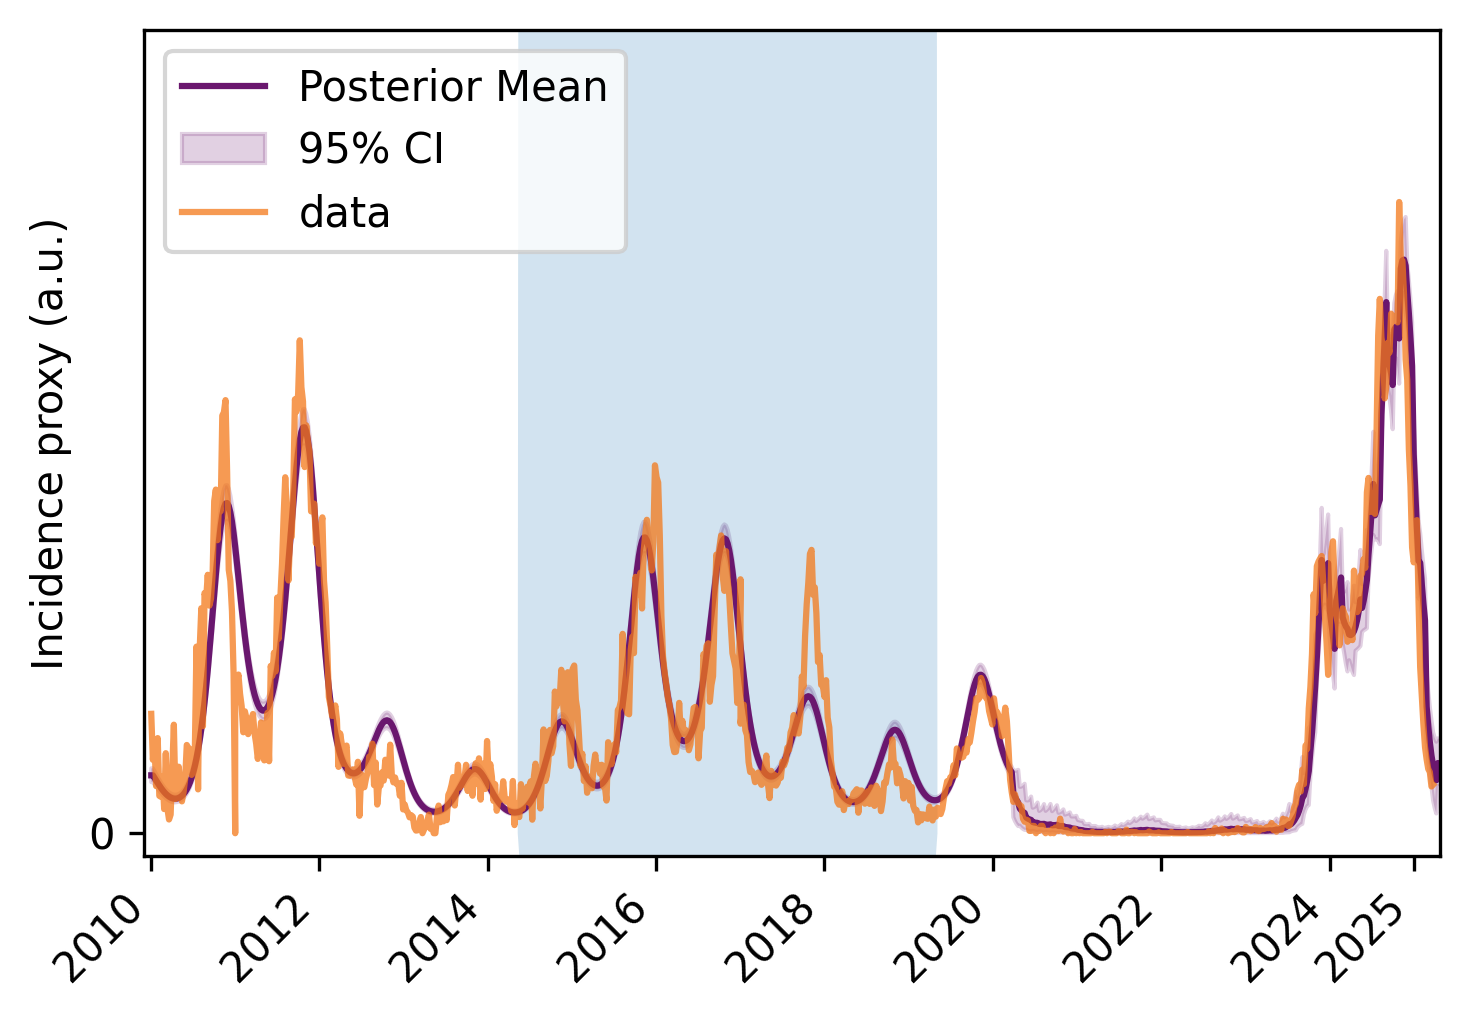

In [14]:
import matplotlib.dates as mdates
from matplotlib.dates import DateFormatter

start_date = df["date"].iloc[0]
#start_date = df["date"].iloc[0] - pd.to_timedelta(5, unit='D')
print(start_date)
n_time_points = v_draws.shape[1]
time_axis = pd.date_range(start=start_date, periods=n_time_points, freq="W-MON")

mean_v = np.mean(v_draws, axis=0)
lower_v = np.percentile(v_draws, 2.5, axis=0)
upper_v = np.percentile(v_draws, 97.5, axis=0)

fig =plt.figure(figsize=(5, 3.5), dpi=300)
plt.plot(time_axis, mean_v, label='Posterior Mean', color=plt.cm.inferno(0.3))
plt.fill_between(time_axis, lower_v, upper_v, color=plt.cm.inferno(0.3), alpha=0.2, label='95% CI')

# Plot data
plt.plot(df["date"], df["value"], "-", label="data", color=plt.cm.inferno(0.7), alpha=0.75)

# Format x-axis as Year-Week if desired
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=24))
#ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-W%V'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))


my_xticks = []
#curr_date = start_date
#while curr_date < time_axis[-1]:
#    my_xticks.append(curr_date)
#    curr_date = curr_date + pd.to_timedelta(2*366, unit='D')

curr_date = pd.to_datetime("2010.1.5")
my_xticks.append(curr_date)

curr_date_int = 2012
curr_date = pd.to_datetime(str(curr_date_int) + ".1") 
while curr_date < time_axis[-1]:
    my_xticks.append(curr_date)
    curr_date_int += 2
    curr_date = pd.to_datetime(str(curr_date_int))

#my_xticks.append(df["date"].iloc[-1])
curr_date = pd.to_datetime("2025.1.1")
my_xticks.append(curr_date)

print(my_xticks)

plt.xticks(my_xticks)
plt.yticks([0])

plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

#plt.xlabel("Time")
plt.ylabel("Incidence proxy (a.u.)")
#plt.title("Posterior Mean and 95% CI for " + var)
plt.legend()
plt.tight_layout()
#plt.xlim([start_date, time_axis[-1]])
plt.xlim([start_date - pd.to_timedelta(30, unit='D'), df["date"].iloc[-1] + pd.to_timedelta(30, unit='D') ])

y_min = -0.01
plt.ylim([y_min, 0.35])

plot_mask = np.logical_and(time_data < t_max, time_data >= t_min)
plt.fill_between(df["date"], plot_mask, y_min*plot_mask, alpha=0.2)


fig.savefig('2025.png', transparent=False, bbox_inches='tight')

[Timestamp('2010-01-05 00:00:00'), Timestamp('2012-01-01 00:00:00'), Timestamp('2014-01-01 00:00:00'), Timestamp('2016-01-01 00:00:00'), Timestamp('2018-01-01 00:00:00'), Timestamp('2020-01-01 00:00:00'), Timestamp('2022-01-01 00:00:00'), Timestamp('2024-01-01 00:00:00'), Timestamp('2026-01-01 00:00:00'), Timestamp('2028-01-01 00:00:00'), Timestamp('2030-01-01 00:00:00'), Timestamp('2032-01-01 00:00:00'), Timestamp('2034-01-01 00:00:00'), Timestamp('2025-01-01 00:00:00')]


(-0.01, 0.3)

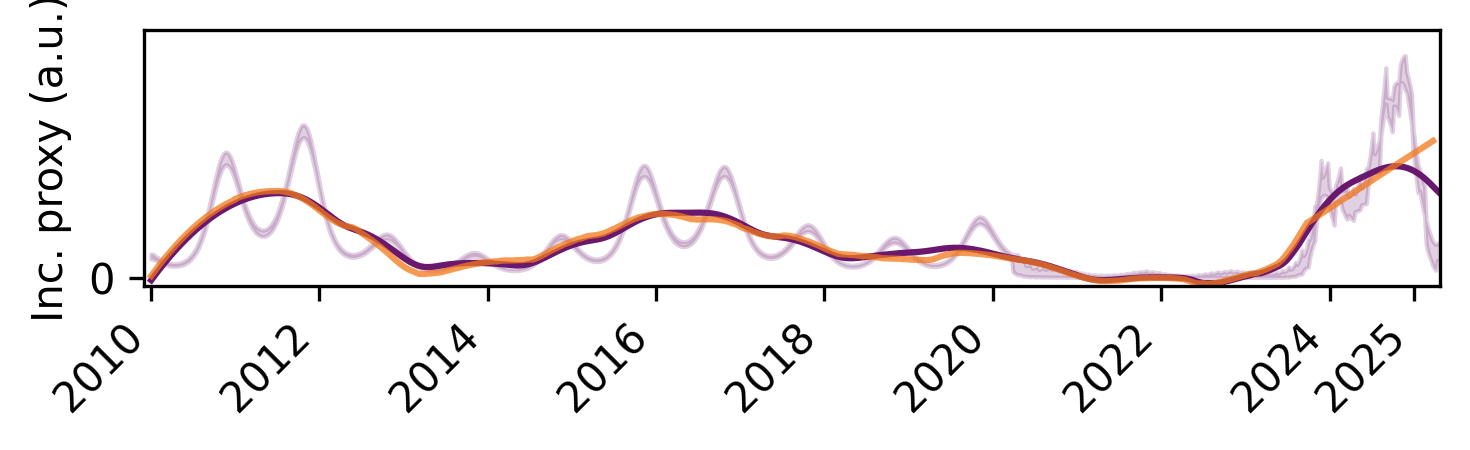

In [22]:
# Smoothed
from scipy.signal import savgol_filter

fig =plt.figure(figsize=(5, 1.6), dpi=300)

var = "Ifit"
v_draws = fit.stan_variable(var)
mean_v = np.mean(v_draws, axis=0)  # average over draws
lower_v = np.percentile(v_draws, 2.5, axis=0)  # 2.5% quantile
upper_v = np.percentile(v_draws, 97.5, axis=0) # 97.5% quantilel



window_length = 52*3
polyorder = 2
fit_smoothed = savgol_filter( mean_v, window_length=window_length, polyorder=polyorder)
plt.plot(time_axis, fit_smoothed, label='Posterior Mean', color=plt.cm.inferno(0.3))
plt.fill_between(time_axis, lower_v, upper_v, color=plt.cm.inferno(0.3), alpha=0.2, label='95% CI')

# Plot data
dat_smoothed = savgol_filter(df["value"], window_length=window_length, polyorder=polyorder)
plt.plot(df["date"], dat_smoothed, "-", label="data", color=plt.cm.inferno(0.7), alpha=0.75)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=24))
#ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-W%V'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))


my_xticks = []
#curr_date = start_date
#while curr_date < time_axis[-1]:
#    my_xticks.append(curr_date)
#    curr_date = curr_date + pd.to_timedelta(2*366, unit='D')

curr_date = pd.to_datetime("2010.1.5")
my_xticks.append(curr_date)

curr_date_int = 2012
curr_date = pd.to_datetime(str(curr_date_int) + ".1") 
while curr_date < time_axis[-1]:
    my_xticks.append(curr_date)
    curr_date_int += 2
    curr_date = pd.to_datetime(str(curr_date_int))

#my_xticks.append(df["date"].iloc[-1])
curr_date = pd.to_datetime("2025.1.1")
my_xticks.append(curr_date)

print(my_xticks)

plt.xticks(my_xticks)
plt.yticks([0])

plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

#plt.xlabel("Time")
plt.ylabel("Inc. proxy (a.u.)")
#plt.title("Posterior Mean and 95% CI for " + var)
#plt.legend()
plt.tight_layout()
#plt.xlim([start_date, time_axis[-1]])
plt.xlim([start_date - pd.to_timedelta(30, unit='D'), df["date"].iloc[-1] + pd.to_timedelta(30, unit='D') ])

y_min = -0.01
plt.ylim([y_min, 0.3])


1317


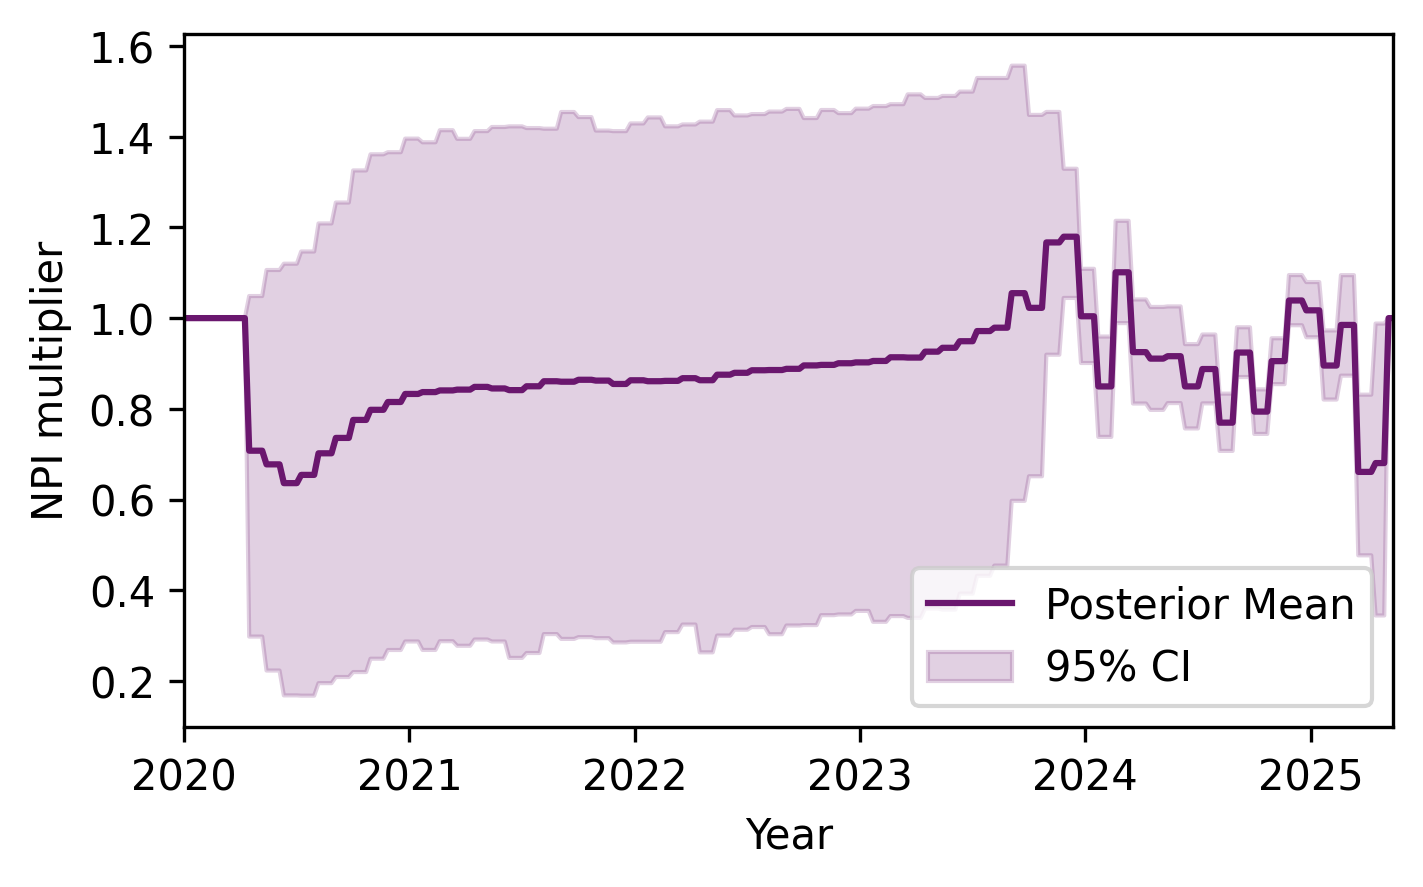

In [23]:
var = "npieff"

v_draws = fit.stan_variable(var)
print(v_draws.shape[1])

plt.figure(figsize=(5.2, 3), dpi=300)

############

mean_v = np.mean(v_draws, axis=0)  # average over draws
lower_v = np.percentile(v_draws, 2.5, axis=0)  # 2.5% quantile
upper_v = np.percentile(v_draws, 97.5, axis=0) # 97.5% quantile

time_fit = np.arange(1, v_draws.shape[1] + 1)/52 + 2010
time_data = np.arange(1, len(df['value']) + 1)/52 + 2010

plt.plot(time_fit, mean_v, label='Posterior Mean', color=plt.cm.inferno(0.3))


plt.fill_between(time_fit, lower_v, upper_v, color=plt.cm.inferno(0.3), alpha=0.2, label='95% CI')

plt.xlabel('Year')
plt.ylabel('NPI multiplier')
plt.legend()

plt.xlim([2020, 2025+4.4/12])

plt.show()


# Per-chain time-series:

In [24]:
import numpy as np
import matplotlib.pyplot as plt

#var = "I"
var = "Ifit"
#var = "beta"
#var = "npi"

S_draws_all = fit.stan_variable(var)

num_chains = fit.chains

draws_per_chain = S_draws_all.shape[0] // num_chains

S_draws_per_chain = S_draws_all.reshape(
    (num_chains, draws_per_chain, S_draws_all.shape[1])
)


Max of chain 1: 0.24985687399999998
Max of chain 2: 0.250320934
Max of chain 3: 0.24974111133333335
Max of chain 4: 0.24985460933333337


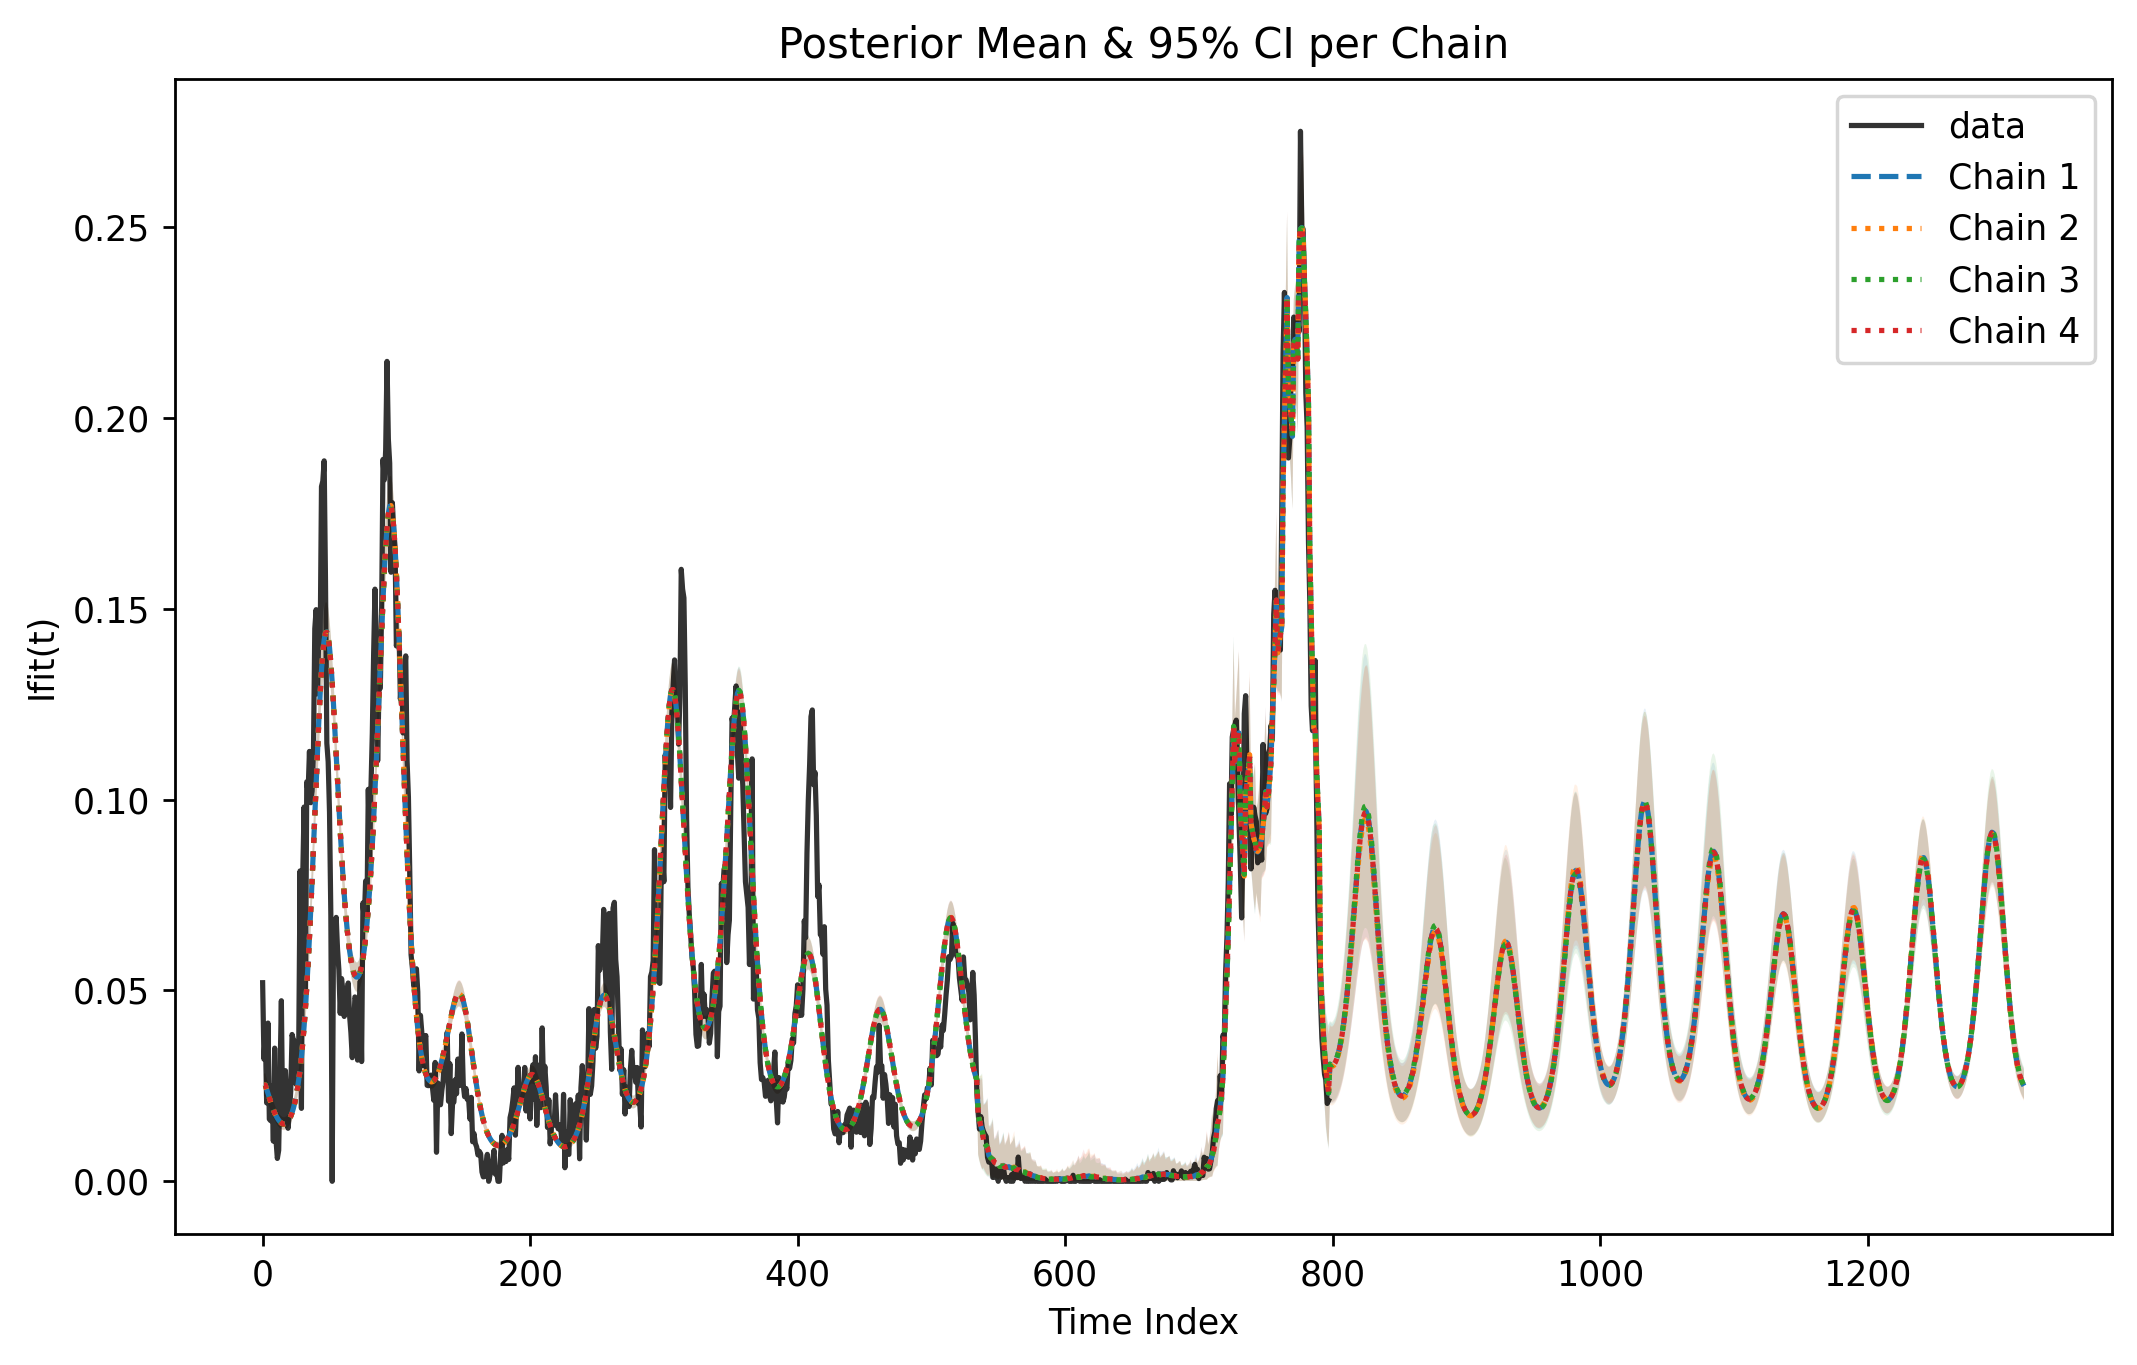

In [25]:
time_idx = np.arange(1, S_draws_per_chain.shape[2] + 1)

plt.figure(figsize=(10, 6), dpi=250)

plot_data = True

excluded_chains = []
#excluded_chains = [1,3,2]


if plot_data:
    plt.plot(df['value'], label="data", color='black', alpha=0.8)

for c in range(num_chains):
    if not (c+1 in excluded_chains):
        chain_data = S_draws_per_chain[c, :, :]  # shape: (draws_per_chain, time_points)
        chain_mean = chain_data.mean(axis=0)
        chain_lower = np.percentile(chain_data, 2.5, axis=0)
        chain_upper = np.percentile(chain_data, 97.5, axis=0)
        print(f"Max of chain {c+1}: {np.max(chain_mean)}")
    
        if c+1 < num_chains/2:
            plt.plot(time_idx, chain_mean, "--", label=f'Chain {c+1}')
        else:
            plt.plot(time_idx, chain_mean, ":", label=f'Chain {c+1}')
        plt.fill_between(time_idx, chain_lower, chain_upper, alpha=0.1)

plt.xlabel("Time Index")
plt.ylabel(f"{var}(t)")
plt.title("Posterior Mean & 95% CI per Chain")
plt.legend()

In [26]:
chain_of_interest = 1
df_draws = fit.draws_pd()

for var in ['S0', 'logx_I0', 'beta0', 'dbeta', 'betaphase', 'sigma_obs', 'logrho', 'delta']:
    c = chain_of_interest-1
    chain_subset = df_draws.iloc[c*draws_per_chain:(c+1)*draws_per_chain]
    mm = np.mean(chain_subset[var].values)
    sd = np.std(chain_subset[var].values)
    print(f"{var}: {mm}")
    if var == "logx_I0":
        print(f"\t(I0 = {10**mm * np.mean(chain_subset["S0"].values)})")
    if var=='delta':
        print(f"1/(mean({var})) = {1/mm:.3f} weeks = {(1/52)*1/mm:.3f} years")
        print(f"+ standard deviation: 1/(mean({var})) = {1/(mm+sd):.3f} weeks = {(1/52)*1/(mm+sd):.3f} years")
        print(f"- standard deviation: 1/(mean({var})) = {1/(mm-sd):.3f} weeks = {(1/52)*1/(mm-sd):.3f} years")

S0: 0.6455142726666666
logx_I0: -2.6408331533333333
	(I0 = 0.0014759535701085724)
beta0: 0.649897118
dbeta: 0.18217197666666668
betaphase: 3.6449831733333333
sigma_obs: 0.016202041733333335
logrho: -1.6737850600000002
delta: 0.002302989453333333
1/(mean(delta)) = 434.218 weeks = 8.350 years
+ standard deviation: 1/(mean(delta)) = 376.357 weeks = 7.238 years
- standard deviation: 1/(mean(delta)) = 513.103 weeks = 9.867 years


# Pairwise posterior plots

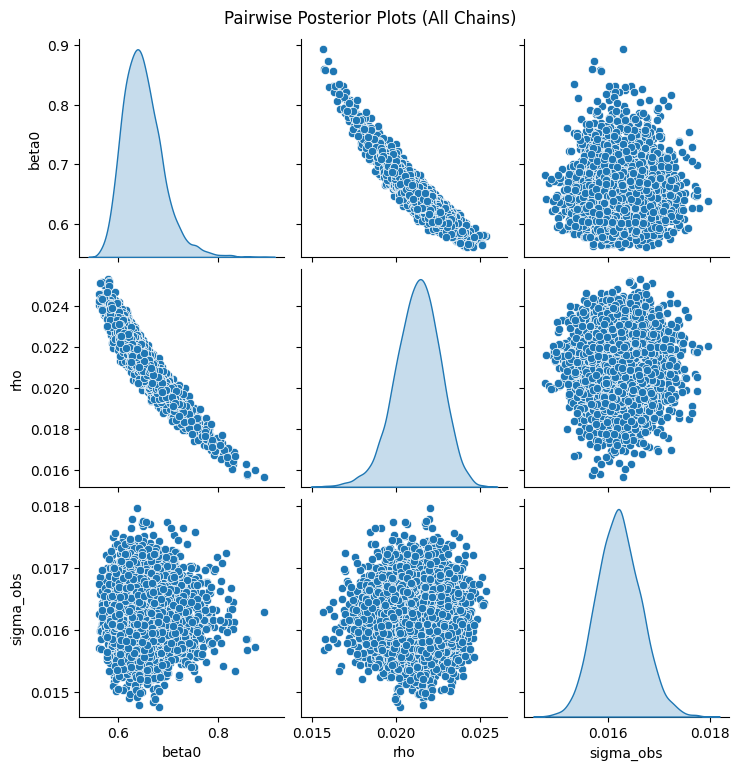

In [27]:
df_draws = fit.draws_pd()

params_of_interest = ["beta0", "rho", "sigma_obs"] 

df_subset = df_draws[params_of_interest]

sns.pairplot(df_subset, diag_kind="kde")
plt.suptitle("Pairwise Posterior Plots (All Chains)", y=1.02)
plt.show()


In [28]:
# Per-chain

In chain 1, averages were: sigma_obs : 0.016202041733333335,   rho : 0.021234657066666666  (mean product: 0.00034402033465928)


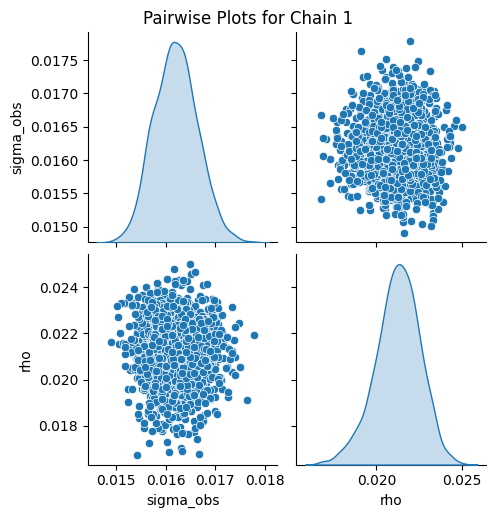

In chain 2, averages were: sigma_obs : 0.016215740266666667,   rho : 0.021427555666666667  (mean product: 0.00034747237186352005)


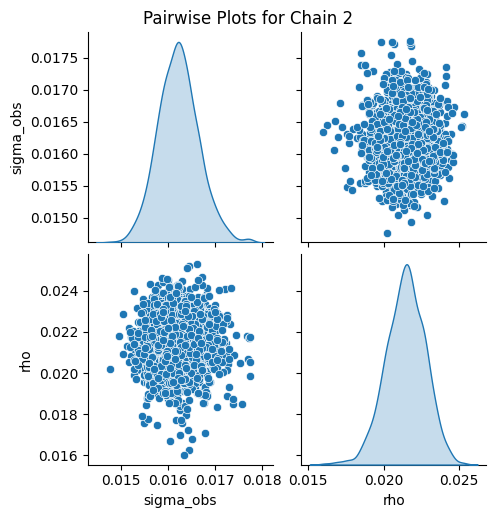

In chain 3, averages were: sigma_obs : 0.016213514533333334,   rho : 0.0211441716  (mean product: 0.00034281684283462004)


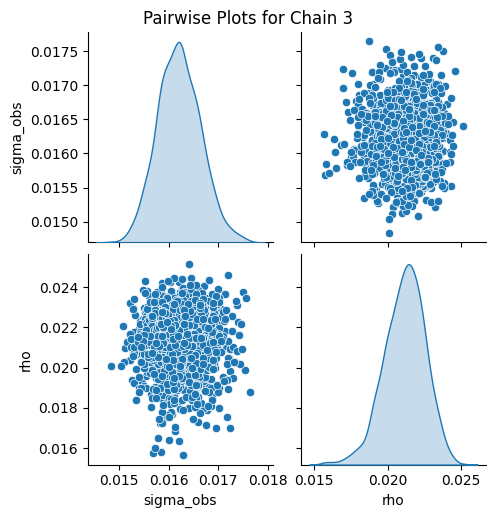

In chain 4, averages were: sigma_obs : 0.0162088702,   rho : 0.021258893733333332  (mean product: 0.00034457295328816663)


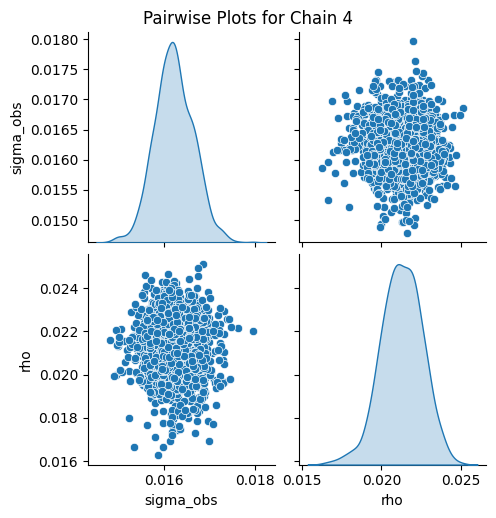

In [29]:
params_of_interest = ["sigma_obs", "rho"]
#params_of_interest = ["S0", "I0"]
#params_of_interest = ["betaphase", "delta"]
#params_of_interest = ["beta0", "rho"]

for c in range(num_chains):
    chain_subset = df_draws.iloc[c*draws_per_chain:(c+1)*draws_per_chain]
    # chain_subset now holds rows for chain c
    p1 = params_of_interest[0]
    p2 = params_of_interest[1]
    mp = np.mean(chain_subset[params_of_interest[0]].values*chain_subset[params_of_interest[1]].values)
    print(f"In chain {c+1}, averages were: {params_of_interest[0]} : {chain_subset[params_of_interest[0]].mean()},   {params_of_interest[1]} : {chain_subset[params_of_interest[1]].mean()}  (mean product: {mp})")
    for p in [p1, p2]:
        if p in ["delta"]:
            print(f"1/{p} = {1/np.mean(chain_subset[p].values)}")
    sns.pairplot(chain_subset[params_of_interest], diag_kind="kde")
    plt.suptitle(f"Pairwise Plots for Chain {c+1}", y=1.02)
    plt.show()
